# Behavioural segmentation of credit-card customers

The supervised half of this project predicts **who** will default. This notebook asks a
different question: **how do customers use credit in the first place?**

Card issuers segment this way in practice. A customer who clears the balance every month
is a different proposition from one who revolves at the limit, even when their risk score
is identical. Segmentation is unsupervised: it never sees the default outcome, so the fact
that segments turn out to differ sharply in risk is a finding rather than a construction.

Three uses in this project:

1. **Reporting.** Performance and fairness can be shown per segment, where a global
   average hides a problem.
2. **Operations.** A per-segment decision threshold can be compared against one global
   threshold.
3. **The research angle.** Explanations should be coherent *within* a segment. If two
   near-identical customers receive different top reasons, the explanation method is
   unstable in a way no single-customer test would reveal.

The logic lives in `backend/app/ml/segmentation.py` and is imported rather than copied, so
this notebook and the running system cannot drift apart.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, silhouette_score
from sklearn.preprocessing import StandardScaler

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
sys.path.insert(0, str(PROJECT_ROOT / "backend"))

from app.ml.feature_engineering import PROTECTED, build_splits
from app.ml.segmentation import (
    CANDIDATE_K,
    LOG_FEATURES,
    SEED,
    SEGMENT_FEATURES,
    choose_k,
    name_segment,
    prepare,
    profile,
)

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\User\Documents\UNI\credit_risk_system


## 1. Which features, and why not all of them

Clustering uses nine engineered features, not all forty-six.

The monthly columns (`PAY_1`–`PAY_6`, `BILL_AMT1`–`BILL_AMT6`, `PAY_AMT1`–`PAY_AMT6`) are
strongly correlated within each block. K-means measures distance across all dimensions
equally, so feeding it the full set would let whichever block has the most columns dominate
the geometry. The result would describe column counts rather than behaviour.

The nine chosen features cover three balanced blocks:

| Block | Features | Captures |
| --- | --- | --- |
| Delinquency | `pay_max`, `pay_months_late`, `pay_trend` | how late, how often, getting better or worse |
| Utilisation | `util_mean`, `util_trend` | how much of the limit is used, and the direction |
| Repayment | `repay_ratio_mean`, `months_zero_payment` | what share of the bill is actually paid |
| Scale | `LIMIT_BAL`, `bill_mean` | size of the relationship |

**The target is excluded**, so segments cannot be a restatement of risk. **Protected
attributes are excluded**, so segments describe behaviour and can later be audited for
fairness without circularity.

In [2]:
frames, y, audit = build_splits(seed=SEED, blind=True)
print({name: len(frame) for name, frame in frames.items()})

train_prepared = prepare(frames["train"])
test_prepared = prepare(frames["test"])

print(f"\nclustering features ({len(SEGMENT_FEATURES)}):")
for feature in SEGMENT_FEATURES:
    note = "  (signed log applied)" if feature in LOG_FEATURES else ""
    print(f"  {feature}{note}")

train_prepared.describe().T[["mean", "std", "min", "50%", "max"]]

{'train': 21000, 'validation': 4500, 'test': 4500}

clustering features (9):
  pay_max
  pay_months_late
  pay_trend
  util_mean
  util_trend
  repay_ratio_mean
  months_zero_payment
  LIMIT_BAL  (signed log applied)
  bill_mean  (signed log applied)


,mean,std,min,50%,max
pay_max,0.4394,1.3401,-2.0000,0.0000,8.0000
pay_months_late,0.8392,1.5563,0.0000,0.0000,6.0000
pay_trend,0.2755,1.1615,-7.0000,0.0000,6.0000
util_mean,0.3725,0.3512,-0.2326,0.2846,5.3643
util_trend,0.1057,0.2977,-1.6142,0.0067,5.3095
repay_ratio_mean,0.6477,24.7004,0.0000,0.1159,"3,333.7499"
months_zero_payment,1.2281,1.7142,0.0000,0.0000,6.0000
LIMIT_BAL,11.6630,0.9416,9.2104,11.8494,13.8155
bill_mean,9.3382,2.6592,-9.9482,9.9515,13.6846


### Skew

`LIMIT_BAL` and `bill_mean` are money, and money is heavily right-skewed. Without a
transform, a handful of very large balances would sit far from everything else and k-means
would spend a cluster on them. A signed log compresses the tail while preserving the
negative balances that appear in `BILL_AMT` when an account is in credit.

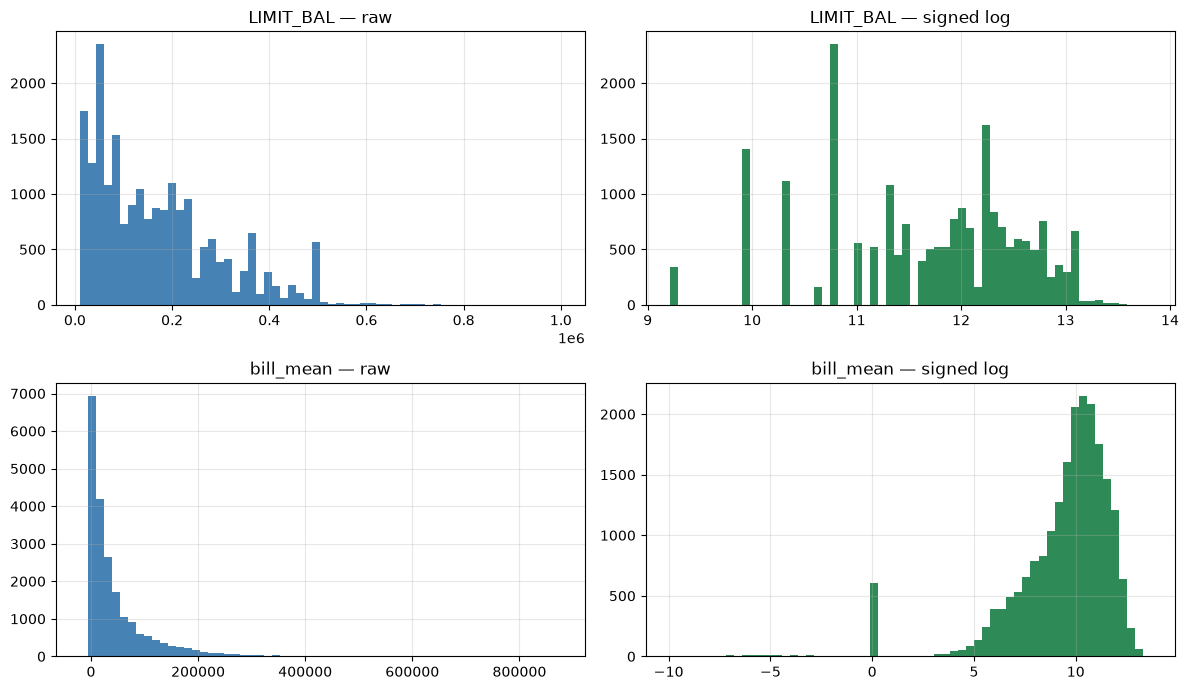

In [3]:
raw_money = frames["train"][["LIMIT_BAL", "bill_mean"]]
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for row, column in enumerate(["LIMIT_BAL", "bill_mean"]):
    axes[row][0].hist(raw_money[column].dropna(), bins=60, color="steelblue")
    axes[row][0].set_title(f"{column} — raw")
    axes[row][1].hist(train_prepared[column].dropna(), bins=60, color="seagreen")
    axes[row][1].set_title(f"{column} — signed log")
plt.tight_layout()
plt.show()

## 2. Scaling

K-means uses Euclidean distance, so a feature measured in hundreds of thousands would
overwhelm one measured in months-late. Everything is standardised to mean 0 and standard
deviation 1.

Imputer and scaler are fitted on the **training split only**, matching how the risk model's
preprocessing is fitted. The test split stays unseen.

In [4]:
imputer = SimpleImputer(strategy="median").fit(train_prepared)
scaler = StandardScaler().fit(imputer.transform(train_prepared))

scaled_train = scaler.transform(imputer.transform(train_prepared))
scaled_test = scaler.transform(imputer.transform(test_prepared))

print(f"scaled train: {scaled_train.shape}")
print(f"column means after scaling (should be ~0): {np.abs(scaled_train.mean(axis=0)).max():.2e}")
print(f"column sds after scaling (should be ~1):   {np.abs(scaled_train.std(axis=0) - 1).max():.2e}")

scaled train: (21000, 9)
column means after scaling (should be ~0): 1.08e-15
column sds after scaling (should be ~1):   2.22e-16


## 3. Choosing k

Two diagnostics, because neither is decisive alone.

**Silhouette** measures how much closer a point sits to its own cluster than to the next
nearest, from −1 to 1. Higher is better; above about 0.5 means strong structure, around 0.25
means weak but real structure.

**Inertia** (the elbow method) is the total squared distance to cluster centres. It always
falls as k rises, so the question is where the fall stops being worth the extra cluster.

Silhouette is O(n²), so it is computed on a 5,000-row sample rather than all 21,000.

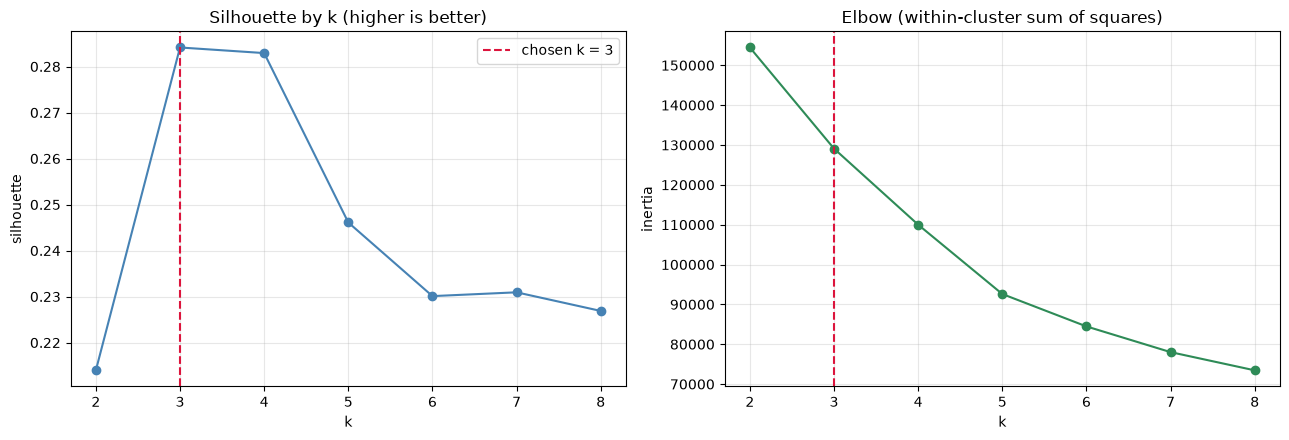

,silhouette,inertia
2,0.2140,"154,467.0650"
3,0.2841,"129,089.3337"
4,0.2829,"109,998.9319"
5,0.2461,"92,600.9622"
6,0.2301,"84,473.9685"
7,0.2309,"78,022.4196"
8,0.2269,"73,450.3458"


In [5]:
best_k, silhouettes = choose_k(scaled_train, seed=SEED)

inertias = {}
for k in CANDIDATE_K:
    inertias[k] = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(scaled_train).inertia_

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(list(silhouettes), list(silhouettes.values()), "o-", color="steelblue")
axes[0].axvline(best_k, color="crimson", ls="--", label=f"chosen k = {best_k}")
axes[0].set_xlabel("k"); axes[0].set_ylabel("silhouette")
axes[0].set_title("Silhouette by k (higher is better)"); axes[0].legend()

axes[1].plot(list(inertias), list(inertias.values()), "o-", color="seagreen")
axes[1].axvline(best_k, color="crimson", ls="--")
axes[1].set_xlabel("k"); axes[1].set_ylabel("inertia")
axes[1].set_title("Elbow (within-cluster sum of squares)")
plt.tight_layout()
plt.show()

pd.DataFrame({"silhouette": silhouettes, "inertia": inertias}).round(4)

**Read the silhouette values honestly.** The winning score is around 0.28, and the runner-up
is within 0.001 of it. That means the structure is real but not sharply separated: customers
sit on a continuum of credit behaviour rather than in four crisp groups. Report this rather
than presenting the chosen k as obviously correct.

## 4. Fit and profile

Clusters are fitted on training rows, then applied to the **test** split for profiling, so
the reported segment risk is measured on customers nobody tuned against.

In [6]:
kmeans = KMeans(n_clusters=best_k, n_init=10, random_state=SEED).fit(scaled_train)
test_labels = kmeans.predict(scaled_test)

profiles = profile(test_prepared, test_labels, y["test"])
segment_table = pd.DataFrame([p.to_dict() for p in profiles])
segment_names = {p.label: p.name for p in profiles}

segment_table[["label", "name", "customers", "share", "default_rate", "distinctive"]]

,label,name,customers,share,default_rate,distinctive
0,0,Moderate user,2757,0.6127,0.1172,"[months_zero_payment low, pay_months_late low,..."
1,1,Distressed,1008,0.2240,0.4802,"[pay_months_late high, pay_max high, util_mean..."
2,2,Dormant,735,0.1633,0.2571,"[months_zero_payment high, bill_mean low, util..."


The names are **heuristic display labels**, assigned by simple rules in
`segmentation.py`'s `name_segment()`. They are a convenience for the dashboard, not a claim.
The numeric profile beside them is the evidence.

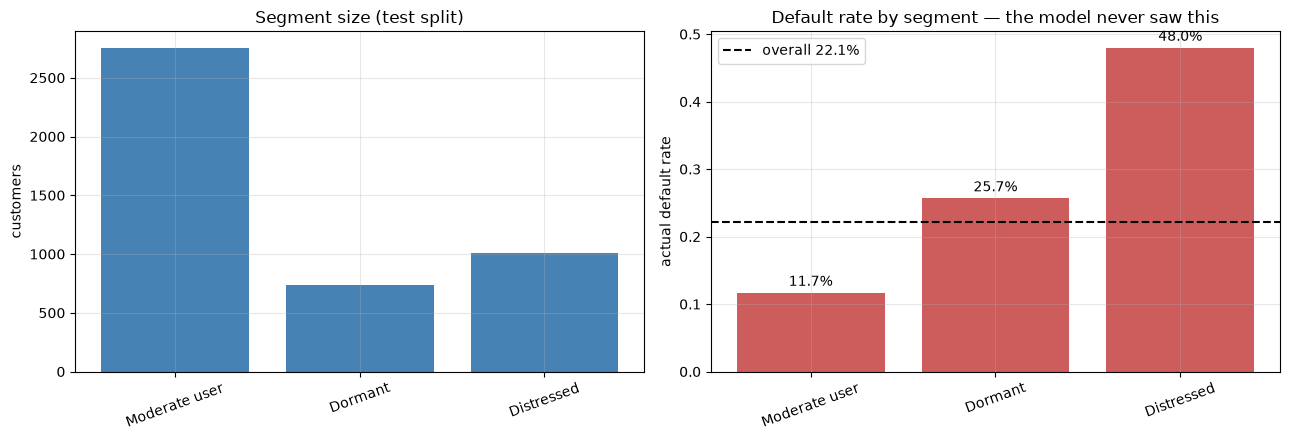

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
order = segment_table.sort_values("default_rate")

axes[0].bar(order["name"], order["customers"], color="steelblue")
axes[0].set_ylabel("customers"); axes[0].set_title("Segment size (test split)")
axes[0].tick_params(axis="x", rotation=20)

bars = axes[1].bar(order["name"], order["default_rate"], color="indianred")
axes[1].axhline(y["test"].mean(), color="black", ls="--",
                label=f"overall {y['test'].mean():.1%}")
axes[1].set_ylabel("actual default rate")
axes[1].set_title("Default rate by segment — the model never saw this")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend()
for bar, value in zip(bars, order["default_rate"]):
    axes[1].text(bar.get_x() + bar.get_width() / 2, value + 0.01, f"{value:.1%}", ha="center")

plt.tight_layout()
plt.show()

This is the headline result of the notebook. The clustering **never saw the default
outcome**, yet the segments separate sharply on risk. Behaviour alone carries most of the
signal the supervised model is also using, which is a useful corroboration of the feature
engineering.

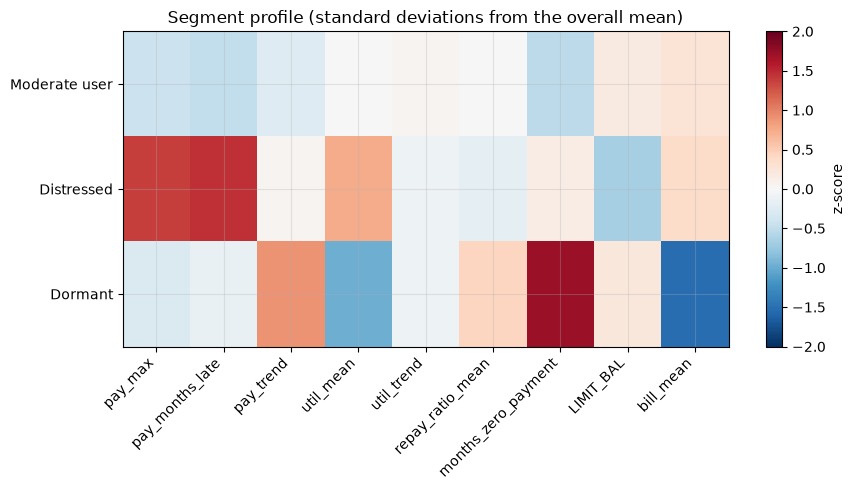

,Moderate user,Distressed,Dormant
pay_max,-0.4300,1.3800,-0.2800
pay_months_late,-0.5000,1.4700,-0.1500
pay_trend,-0.2600,0.0500,0.9000
util_mean,-0.0100,0.7400,-0.9700
util_trend,0.0600,-0.1000,-0.0900
repay_ratio_mean,-0.0100,-0.1800,0.4200
months_zero_payment,-0.5200,0.1500,1.7300
LIMIT_BAL,0.1800,-0.6700,0.2200
bill_mean,0.2700,0.3700,-1.5200


In [8]:
# What actually distinguishes each segment, in standard deviations from the overall mean.
overall = test_prepared.mean()
spread = test_prepared.std().replace(0, np.nan)

z = pd.DataFrame(
    {
        segment_names[label]: (test_prepared.loc[test_labels == label].mean() - overall) / spread
        for label in sorted(set(test_labels))
    }
)

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(z.T.to_numpy(), cmap="RdBu_r", vmin=-2, vmax=2, aspect="auto")
ax.set_xticks(range(len(z.index))); ax.set_xticklabels(z.index, rotation=45, ha="right")
ax.set_yticks(range(len(z.columns))); ax.set_yticklabels(z.columns)
ax.set_title("Segment profile (standard deviations from the overall mean)")
plt.colorbar(im, label="z-score")
plt.tight_layout()
plt.show()

z.round(2)

## 5. Visualising the segments

The nine clustering features are projected to two dimensions with PCA so the separation can
be seen. PCA is used only for display; the clustering happens in the full nine-dimensional
space.

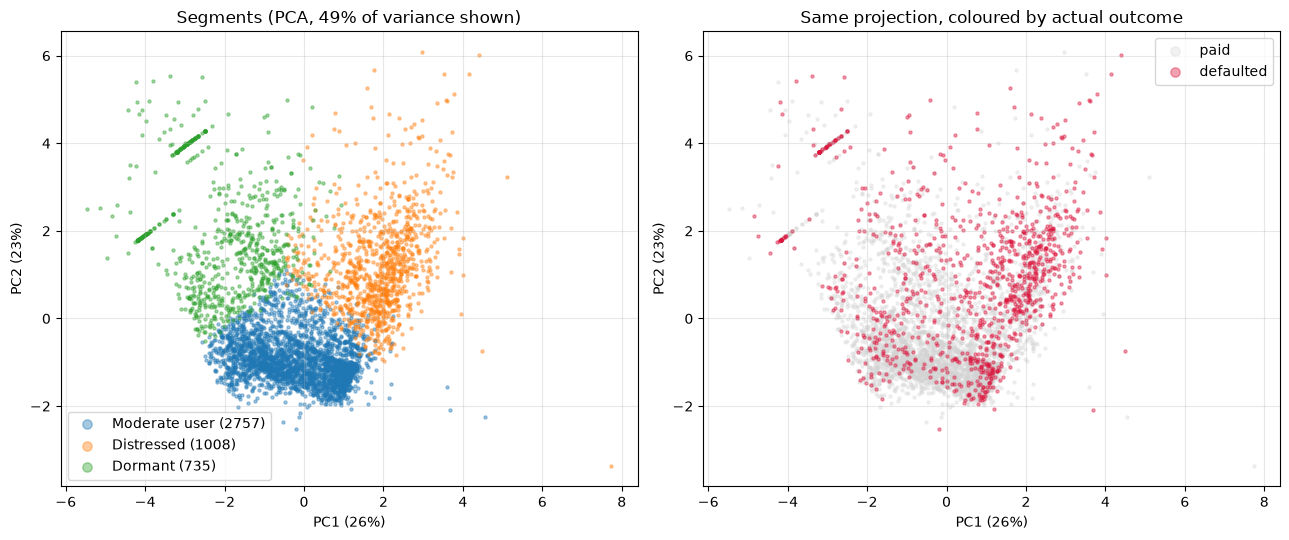

In [9]:
projection = PCA(n_components=2, random_state=SEED).fit(scaled_train)
points = projection.transform(scaled_test)
explained = projection.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for label in sorted(set(test_labels)):
    mask = test_labels == label
    axes[0].scatter(points[mask, 0], points[mask, 1], s=5, alpha=0.4,
                    label=f"{segment_names[label]} ({mask.sum()})")
axes[0].set_title(f"Segments (PCA, {explained.sum():.0%} of variance shown)")
axes[0].legend(markerscale=3)

defaulted = y["test"].to_numpy().astype(bool)
axes[1].scatter(points[~defaulted, 0], points[~defaulted, 1], s=5, alpha=0.3,
                color="lightgrey", label="paid")
axes[1].scatter(points[defaulted, 0], points[defaulted, 1], s=5, alpha=0.4,
                color="crimson", label="defaulted")
axes[1].set_title("Same projection, coloured by actual outcome")
axes[1].legend(markerscale=3)

for ax in axes:
    ax.set_xlabel(f"PC1 ({explained[0]:.0%})"); ax.set_ylabel(f"PC2 ({explained[1]:.0%})")
plt.tight_layout()
plt.show()

Comparing the two panels shows how much of the risk signal is behavioural. Where the
defaulters in the right panel concentrate in one region of the left panel, the segment
boundary is carrying real information.

## 6. Are the segments demographic proxies?

This check decides whether the segments are usable for fairness work at all.

If a segment turned out to be, say, 90% one sex, then "per-segment" analysis would quietly
become per-demographic analysis, and any fairness conclusion drawn from it would be
circular. The clustering never saw these attributes, but a proxy could still emerge through
correlated behaviour.

In [10]:
composition_rows = []
for attribute in [a for a in PROTECTED if a != "AGE"]:
    values = audit["test"][attribute].to_numpy()
    baseline = pd.Series(values).value_counts(normalize=True)
    for label in sorted(set(test_labels)):
        shares = pd.Series(values[test_labels == label]).value_counts(normalize=True)
        composition_rows.append(
            {
                "attribute": attribute,
                "segment": segment_names[label],
                **{f"group {group}": round(shares.get(group, 0.0), 3) for group in baseline.index},
                "max shift vs baseline": round(
                    max(abs(shares.get(g, 0.0) - baseline[g]) for g in baseline.index), 3
                ),
            }
        )

composition = pd.DataFrame(composition_rows)
print("A large 'max shift vs baseline' would indicate a demographic proxy.\n")
composition

A large 'max shift vs baseline' would indicate a demographic proxy.



,attribute,segment,group 2,group 1,max shift vs baseline,group 3,group 4
0,SEX,Moderate user,0.6090,0.3910,0.0010,NaN,NaN
1,SEX,Distressed,0.5740,0.4260,0.0330,NaN,NaN
2,SEX,Dormant,0.6490,0.3510,0.0410,NaN,NaN
3,EDUCATION,Moderate user,0.4600,0.3630,0.0120,0.1590,0.0180
4,EDUCATION,Distressed,0.5370,0.2530,0.0980,0.2070,0.0030
5,EDUCATION,Dormant,0.3780,0.4390,0.0880,0.1630,0.0190
6,MARRIAGE,Moderate user,0.5300,0.4600,0.0010,0.0110,NaN
7,MARRIAGE,Distressed,0.5430,0.4440,0.0140,0.0130,NaN
8,MARRIAGE,Dormant,0.5100,0.4730,0.0190,0.0160,NaN


In [11]:
age_bands = pd.cut(audit["test"]["AGE"], [20, 30, 40, 50, 60, 100],
                   labels=["21-30", "31-40", "41-50", "51-60", "60+"])
age_mix = pd.crosstab(
    pd.Series([segment_names[l] for l in test_labels], index=audit["test"].index),
    age_bands, normalize="index",
)
print("Age band mix per segment (rows sum to 1):")
age_mix.round(3)

Age band mix per segment (rows sum to 1):


AGE,21-30,31-40,41-50,51-60,60+
row_0,,,,,
Distressed,0.4380,0.2920,0.1940,0.0690,0.0070
Dormant,0.2990,0.4160,0.1930,0.0730,0.0180
Moderate user,0.3460,0.3730,0.2070,0.0690,0.0050


## 7. Does the risk model perform equally well in every segment?

A global AUC can hide a model that works well for most customers and poorly for one group.
Since the segments are behavioural rather than demographic, this is a performance question
rather than a fairness one, but it is measured the same way.

In [12]:
from app.ml.scorer import CreditScorer
from app.ml.feature_engineering import load_taiwan

scorer = CreditScorer()
raw = load_taiwan()
scores = scorer.probabilities(raw.loc[frames["test"].index])

rows = []
for label in sorted(set(test_labels)):
    mask = test_labels == label
    segment_y = y["test"].to_numpy()[mask]
    if len(np.unique(segment_y)) < 2:
        continue
    rows.append({
        "segment": segment_names[label],
        "customers": int(mask.sum()),
        "default_rate": float(segment_y.mean()),
        "auc": roc_auc_score(segment_y, scores[mask]),
        "mean_predicted": float(scores[mask].mean()),
    })

per_segment = pd.DataFrame(rows).set_index("segment")
per_segment["calibration_gap"] = per_segment["mean_predicted"] - per_segment["default_rate"]
print(f"Overall test AUC: {roc_auc_score(y['test'], scores):.4f}\n")
per_segment.round(4)

Overall test AUC: 0.7811



,customers,default_rate,auc,mean_predicted,calibration_gap
segment,,,,,
Moderate user,2757,0.1172,0.6706,0.1147,-0.0024
Distressed,1008,0.4802,0.7397,0.4897,0.0096
Dormant,735,0.2571,0.6720,0.2566,-0.0006


Two things to read here.

**AUC per segment** shows whether ranking quality holds everywhere. A low AUC inside a
segment is expected when that segment is internally homogeneous — if almost everyone in it
behaves the same way, there is little left to rank, even when the segment's overall risk
level is predicted correctly.

**Calibration gap** is mean predicted probability minus actual default rate. Near zero means
the model's probabilities are honest for that segment. A consistently positive or negative
gap in one segment would be a genuine problem, because the risk bands shown to a loan
officer would be wrong for those customers.

## Handoff

The fitted segmenter is written to `backend/artifacts/` by
`python -m app.ml.segmentation`, and the dashboard reads it from there. Nothing in this
notebook needs to run for the system to work.

Next, in `notebooks/explanations.ipynb`: segments become the basis for the project's
research angle. If two customers sit in the same behavioural segment and receive different
top explanation reasons, the explanation method is inconsistent. That is measurable, it
needs no human participants, and it is the question this project sets out to answer.